In [ ]:
import numpy as np
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from tqdm.notebook import tqdm

In [ ]:
def plot_decision_boundary(model, X, y):
    # Set min and max values and give it some padding
    x_min, x_max = X[0, :].min() - 0.5, X[0, :].max() + 0.5
    y_min, y_max = X[1, :].min() - 0.5, X[1, :].max() + 0.5
    h = 0.01

    # Generate a grid of points with distance h between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    grid_X = np.c_[xx.ravel(), yy.ravel()].T
    Z = model.predict(grid_X)
    Z = (Z > 0.5).astype(int)
    Z = Z.reshape(xx.shape)

    # Plot the contour and the training examples
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
    plt.scatter(X[0, :], X[1, :], c=y.flatten(), cmap=plt.cm.Spectral, edgecolors='k')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Decision Boundary for Neural Network')
    plt.show()

In [ ]:
 class Layer:
  def forward(self, X):
    pass
  def backward(self, dA_L, lr):
    pass

class Dense(Layer):
  def __init__(self, n_in, n_out):
    """
    Initialize the layer and its weights with He initialization
    W.shape = (n_in, n_out)
    b.shape = (n_out, 1)
    """
    self.W = np.random.randn(n_in, n_out) * np.sqrt(2 / n_in)
    self.b = np.zeros((n_out, 1))

  def forward(self, X):
    """
    Carry out the forward pass
    Args:
         X: Data matrix of column vectors i.e. (n, m)
         n: features
         m: number of samples
    returns:
      Z = W.T @ X + b
      (n_out, m) = (n_out, n_in) @ (n_in, m) + (n_out, 1)
    """
    self.X = X
    self.Z = self.W.T @ X + self.b
    return self.Z

  def backward(self, dZ_L, lr):
    """
    Carry out the backward pass
    Args:
      dZ_L: incoming gradient of shape (n_out, m)
    returns:
      dW: X @ dZ_L^T (n_in, n_out)
      db: dZ_L (n_out, 1)
      dA_Prev: W @ dZ_L (n_in, m)
    """
    m = self.X.shape[1]
    self.dW = self.X @ dZ_L.T / m
    self.db = np.sum(dZ_L, axis=1, keepdims=True) / m
    dA_Prev = self.W @ dZ_L

    self.W -= lr * self.dW  # update params
    self.b -= lr * self.db  # update params

    return dA_Prev

class Activation(Layer):
  def __init__(self, activation_name):
    self.name = activation_name
    self.activations = {
        'relu': lambda x: np.maximum(0, x),
        'sigmoid': lambda x: 1/(1+np.exp(-x)),
        'tanh': lambda x: np.tanh(x)
        # 'softmax': lambda x: np.exp(x) / np.sum(np.exp(x), axis=0)
    }
    self.derivatives = {
        'relu': lambda x: (x > 0).astype(float),
        'sigmoid': lambda x: self.activations['sigmoid'](x) * (1 - self.activations['sigmoid'](x)),
        'tanh': lambda x: 1 - np.tanh(x)**2
    }

  def forward(self, Z):
    """
    Z: output of the dense layer (n_out, m)
    returns:
      A = activation(Z) (n_out, m)
    """
    self.Z = Z
    self.A = self.activations[self.name](Z)
    return self.A

  def backward(self, dA_L, lr):
    """
    dA_L: incoming gradient (n_out, m)
    returns:
      dZ = dA_L * g'(Z) (n_in, m)
    """
    return dA_L * self.derivatives[self.name](self.Z)

class NeuralNet():
  def __init__(self):
    self.layers = []
    self.loss_history = []

  def add(self, layer):
    self.layers.append(layer)

  def predict(self, X):
    op = X
    for layer in self.layers:
      op = layer.forward(op)
    return op

  def train(self, X, y, epochs=100, lr=0.01):
    """
    X: (n_features, m_samples) column vectors
    y: (1, m_samples)
    """
    m = X.shape[1]

    # Forward pass
    pbar = tqdm(range(epochs), desc="Training Neural Network")
    for epoch in pbar:
      op = X
      for layer in self.layers:
        op = layer.forward(op)

      # Calculate loss (BCE)
      op = np.clip(op, 1e-15, 1 - 1e-15)
      loss = -1/m * np.sum(y * np.log(op) + (1 - y) * (np.log(1 - op)))
      self.loss_history.append(loss)

      # Backward pass
      grad = - (y/op - (1 - y) / (1 - op))

      for layer in reversed(self.layers):
        grad = layer.backward(grad, lr)

      # Update the progress bar with the current loss
      pbar.set_postfix(loss=f"{loss:.4f}")

In [ ]:
# 1. Prepare Data
X_raw, y_raw = make_moons(n_samples=500, noise=0.1, random_state=42)

# X shape: (2, 500) -> 2 Features, 500 Samples
X = X_raw.T

# y shape: (1, 500) -> 1 Output, 500 Samples
y = y_raw.reshape(1, -1)

# 2. Build Model
nn = NeuralNet()

# Layer 1: 3 Neurons (n_in, n_out) -> (2,3)
nn.add(Dense(2, 5))
nn.add(Activation('relu'))

# Layer 2: 2 Neurons (n_in, n_out) -> (3,2)
nn.add(Dense(5, 3))
nn.add(Activation('relu'))

# Layer 3: 1 Neuron (n_in, n_out) -> (2,1)
nn.add(Dense(3, 1))
nn.add(Activation('sigmoid'))

# 3. Train
nn.train(X, y, epochs=500, lr=0.1)

Training Neural Network:   0%|          | 0/500 [00:00<?, ?it/s]

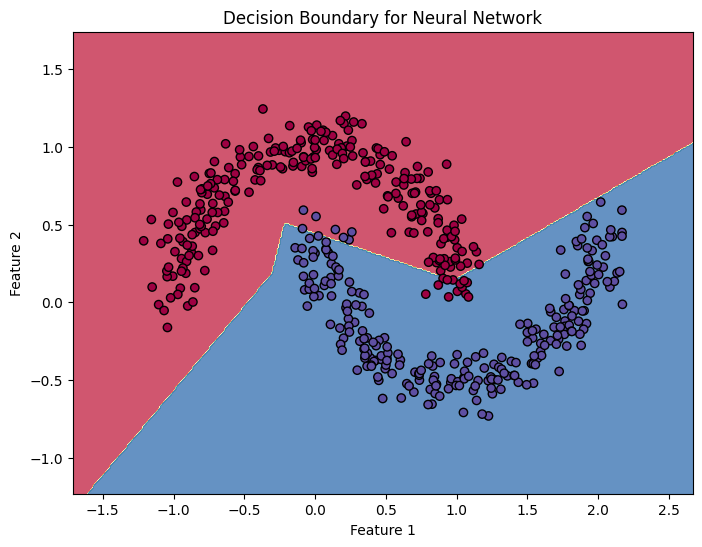

In [ ]:
plot_decision_boundary(nn, X, y)

In [ ]:
# Predict
y_pred = nn.predict(X)
y_pred_binary = (y_pred > 0.5).astype(float).reshape(1, -1)

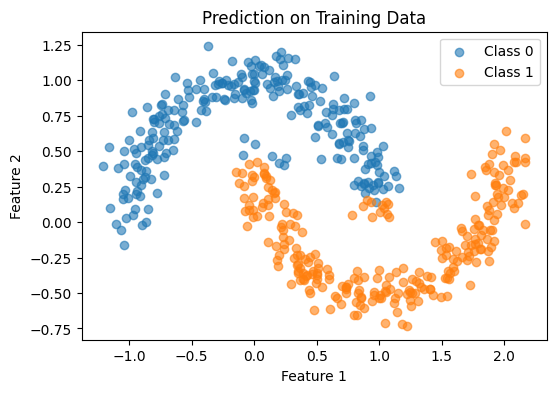

In [ ]:
# Prediction on training data
plt.figure(figsize=(6, 4))
plt.scatter(X[0, y_pred_binary.flatten() == 0], X[1, y_pred_binary.flatten() == 0], label='Class 0', alpha=0.6)
plt.scatter(X[0, y_pred_binary.flatten() == 1], X[1, y_pred_binary.flatten() == 1], label='Class 1', alpha=0.6)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.title('Prediction on Training Data')
plt.show()

In [ ]:
# Calculate accuracy
accuracy = np.mean(y_pred_binary == y)
print(f"Accuracy: {accuracy:.4f}")

# Calculate precision, recall, and F1-score

precision = precision_score(y.flatten(), y_pred_binary.flatten())
recall = recall_score(y.flatten(), y_pred_binary.flatten())
f1 = f1_score(y.flatten(), y_pred_binary.flatten())

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y.flatten(), y_pred_binary.flatten())
print(f"\nConfusion Matrix:\n{cm}")

# Calculate specificity and sensitivity
# tn, fp, fn, tp = cm.ravel()
# specificity = tn / (tn + fp)
# sensitivity = tp / (tp + fn)
# print(f"\nSensitivity (True Positive Rate): {sensitivity:.4f}")
# print(f"Specificity (True Negative Rate): {specificity:.4f}")

Accuracy: 0.9620
Precision: 0.9529
Recall: 0.9720
F1-Score: 0.9624

Confusion Matrix:
[[238  12]
 [  7 243]]
